
Br_R1s(r) =
+408.1683 * exp(-35.7147 r)
+286.0782 * r * exp(-30.2313 r)
-1.7033 * r * exp(-16.2817 r)
+1570.3261 * r^2 * exp(-43.9396 r)
-0.6362 * r^2 * exp(-12.1552 r)
-0.0112 * r^2 * exp(-8.3109 r)
-0.0004 * r^2 * exp(-5.9392 r)
+55.6131 * r^3 * exp(-18.9651 r)
-0.0001 * r^3 * exp(-3.6167 r)
+0.0000 * r^3 * exp(-2.4340 r)
+0.0000 * r^3 * exp(-1.6936 r)

Br_R2s(r) =
+128.0902 * exp(-35.7147 r)
+1300.1260 * r * exp(-30.2313 r)
-1211.6943 * r * exp(-16.2817 r)
-0.7113 * r^2 * exp(-43.9396 r)
-353.6641 * r^2 * exp(-12.1552 r)
+6.8485 * r^2 * exp(-8.3109 r)
-0.9005 * r^2 * exp(-5.9392 r)
-7796.1157 * r^3 * exp(-18.9651 r)
+0.0225 * r^3 * exp(-3.6167 r)
-0.0020 * r^3 * exp(-2.4340 r)
+0.0001 * r^3 * exp(-1.6936 r)

Br_R3s(r) =
-50.9078 * exp(-35.7147 r)
-610.6963 * r * exp(-30.2313 r)
+576.1826 * r * exp(-16.2817 r)
-124.7156 * r^2 * exp(-43.9396 r)
+344.0518 * r^2 * exp(-12.1552 r)
-404.3534 * r^2 * exp(-8.3109 r)
-138.7126 * r^2 * exp(-5.9392 r)
+8048.5330 * r^3 * exp(-18.9651 r)
-0.316

/tmp/ipykernel_1139/2965071075.py:147: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 0.9999926462919414
Norm 2s = 0.9999981825659316
Norm 2p = 1.000001100445226
Norm 3s = 1.000000404595629
Norm 3p = 0.9999996784389945
Norm 3d = 1.000000916699535
Norm 4s = 0.9999999265260068
Norm 4p = 1.0000002658394114
           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00           0.024802           0.090924       2.361661e-01   
1       0.05           0.024802           0.090916       2.360150e-01   
2       0.10           0.024801           0.090893       2.355622e-01   
3       0.15           0.024801           0.090855       2.348099e-01   
4       0.20           0.024799           0.090802       2.337614e-01   
...      ...                ...                ...                ...   
1996   99.80           0.000031           0.000004       5.642442e-07   
1997   99.85           0.000031           0.000003       5.626544e-07   
1998   99.90           0.000031           0.000003       5.610697e-07   
1999   99.95           0.000030          

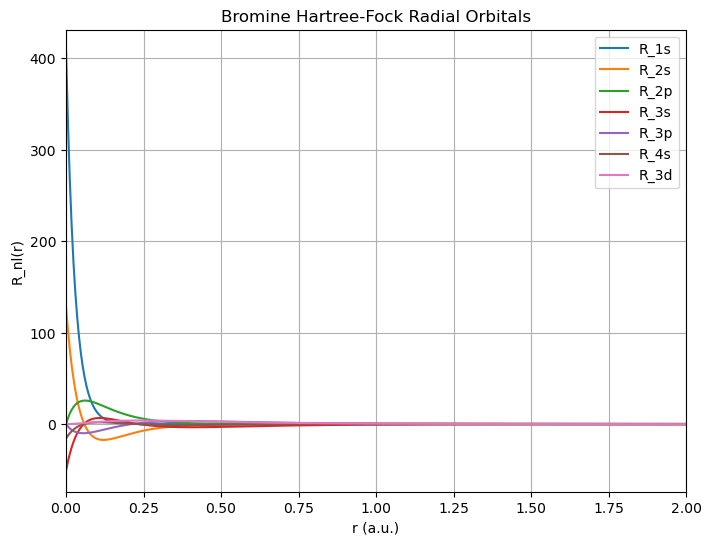

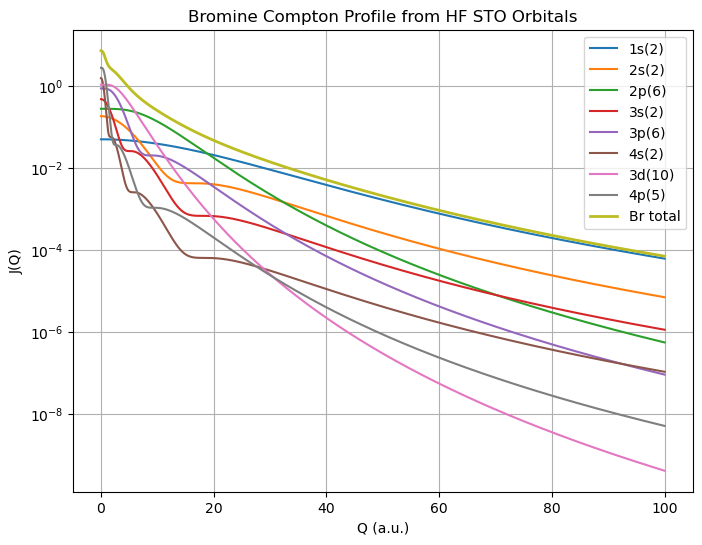

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Bromine Hartree-Fock STO data
# Br: 1s2 2s2 2p6 3s2 3p6 3d10 4s2 4p5
# Format: (n_j, Z_j, C_j)
# =====================================================

bromine_1s = [
    (1, 35.7147,  0.956178),
    (2, 30.2313,  0.049303),
    (2, 16.2817, -0.001379),
    (3, 43.9396,  0.006623),
    (3, 12.1552, -0.000241),
    (3,  8.3109, -0.000016),
    (3,  5.9392, -0.000002),
    (4, 18.9651,  0.000876),
    (4,  3.6167, -0.000002),
    (4,  2.4340,  0.000003),
    (4,  1.6936,  0.000000),
]

bromine_2s = [
    (1, 35.7147,  0.300065),
    (2, 30.2313,  0.224065),
    (2, 16.2817, -0.981012),
    (3, 43.9396, -0.000003),
    (3, 12.1552, -0.133963),
    (3,  8.3109,  0.009815),
    (3,  5.9392, -0.004183),
    (4, 18.9651, -0.122802),
    (4,  3.6167,  0.000613),
    (4,  2.4340, -0.000317),
    (4,  1.6936,  0.000109),
]

bromine_3s = [
    (1, 35.7147, -0.119257),
    (2, 30.2313, -0.105248),
    (2, 16.2817,  0.466489),
    (3, 43.9396, -0.000526),
    (3, 12.1552,  0.130322),
    (3,  8.3109, -0.579501),
    (3,  5.9392, -0.644361),
    (4, 18.9651,  0.126778),
    (4,  3.6167, -0.008641),
    (4,  2.4340,  0.001333),
    (4,  1.6936, -0.000566),
]

bromine_4s = [
    (1, 35.7147, -0.036545),
    (2, 30.2313, -0.033223),
    (2, 16.2817,  0.147307),
    (3, 43.9396, -0.000106),
    (3, 12.1552,  0.038175),
    (3,  8.3109, -0.196982),
    (3,  5.9392, -0.269614),
    (4, 18.9651,  0.046308),
    (4,  3.6167,  0.459442),
    (4,  2.4340,  0.530326),
    (4,  1.6936,  0.160145),
]

bromine_2p = [
    (2, 36.6717,  0.059746),
    (2, 13.9922,  0.734105),
    (3, 30.1518,  0.132860),
    (3, 10.8966,  0.033198),
    (3,  7.0906,  0.000750),
    (3,  5.0673,  0.000664),
    (4, 24.3902,  0.088869),
    (4,  3.2746, -0.000063),
    (4,  2.0783,  0.000011),
    (4,  1.3411, -0.000011),
]

bromine_3p = [
    (2, 36.6717, -0.005460),
    (2, 13.9922, -0.499743),
    (3, 30.1518, -0.000944),
    (3, 10.8966,  0.148906),
    (3,  7.0906,  0.643268),
    (3,  5.0673,  0.379137),
    (4, 24.3902,  0.022016),
    (4,  3.2746,  0.005992),
    (4,  2.0783,  0.000647),
    (4,  1.3411,  0.000313),
]

bromine_4p = [
    (2, 36.6717, -0.000217),
    (2, 13.9922, -0.142598),
    (3, 30.1518,  0.003309),
    (3, 10.8966,  0.049718),
    (3,  7.0906,  0.184443),
    (3,  5.0673,  0.118116),
    (4, 24.3902,  0.009707),
    (4,  3.2746, -0.380018),
    (4,  2.0783, -0.537214),
    (4,  1.3411, -0.232420),
]

bromine_3d = [
    (3, 18.4910,  0.015518),
    (3, 10.2980,  0.242791),
    (3,  6.4197,  0.459169),
    (3,  4.2010,  0.351558),
    (3,  2.6377,  0.039199),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, bromine_1s)
R2s = R_nl(r, bromine_2s)
R3s = R_nl(r, bromine_3s)
R4s = R_nl(r, bromine_4s)
R2p = R_nl(r, bromine_2p)
R3p = R_nl(r, bromine_3p)
R4p = R_nl(r, bromine_4p)
R3d = R_nl(r, bromine_3d)

print_R_formula(bromine_1s, "Br_R1s")
print_R_formula(bromine_2s, "Br_R2s")
print_R_formula(bromine_3s, "Br_R3s")
print_R_formula(bromine_4s, "Br_R4s")
print_R_formula(bromine_2p, "Br_R2p")
print_R_formula(bromine_3p, "Br_R3p")
print_R_formula(bromine_3d, "Br_R3d")
print_R_formula(bromine_4p, "Br_R4p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_4p = chi_p(p, r, R4p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_4p, J_4p = calculate_J(p, chi_4p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))
print("Norm 4p =", np.trapezoid(I_4p, p))

# Krypton has  1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(2) 4p(5)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 10*J_3d + 2*J_4s + 5*J_4p

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_3d_one_electron": J_3d,
    "J_4s_one_electron": J_4s,
    "J_4p_one electron": J_4p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(6)": 6*J_3p,
    "J_4s(1)": 2*J_4s,
    "J_3d(10)": 10*J_3d,
    "J_4p(5)": 5*J_4p,
    "J_total_Br": J_total
    })
print(table)
table.to_csv("Bromine__STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Bromine Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 10*J_3d, label="3d(10)")
plt.plot(Q, 5*J_4p, label="4p(5)")
plt.plot(Q, J_total, label="Br total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Bromine Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()
